<a href="https://colab.research.google.com/github/Sharddha-Sharddha/IITMLAssignments/blob/main/AMAZON_fine_food_review_RNN%7CLSTM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **#Amazon Fine Food Reviews**
Analyze ~500,000 food reviews from Amazon

This project is a Sentiment Analysis pipeline using the Amazon Fine Food Reviews dataset.


* **Goal**: To predict whether a food review is positive or negative based on the text.

* **Process**: You cleaned the text (removing HTML, special characters), tokenized it into numbers, and padded the sequences so they all have the same length.

* **Experiment**: built three different types of "**Recurrent**" Neural Networks (**SimpleRNN, LSTM, GRU , Bidirectionla GRU and Bidirectional LSTM** ) to compare which one is best at understanding the "context" and "order" of words in a review.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

os is used to connect directly with the dataset by taking the cache

In [2]:
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
csv_file = os.path.join(path,'Reviews.csv')
df = pd.read_csv(csv_file)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [3]:
df.head(2)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...


In [4]:
df.shape

(568454, 10)

In [5]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


we only need user's text and score

In [6]:
df_clean = df[['Score','Text']]

In [7]:
df_clean

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...
...,...,...
568449,5,Great for sesame chicken..this is a good if no...
568450,2,I'm disappointed with the flavor. The chocolat...
568451,5,"These stars are small, so you can give 10-15 o..."
568452,5,These are the BEST treats for training and rew...


In [8]:
df_clean.isnull().sum()

,0
Score,0
Text,0


In [9]:
df_clean['Text'][2]

'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.'

In [10]:
df_clean['Score'][2]

np.int64(4)

In [11]:
#rating distribution
score_counts = df_clean['Score'].value_counts().sort_index()
print('\nPercentage')
for score, count in score_counts.items():
  perc = (count/len(df_clean)) * 100
  print(f"{score} 🌟 : {perc:.2f}%")


Percentage
1 🌟 : 9.19%
2 🌟 : 5.24%
3 🌟 : 7.50%
4 🌟 : 14.19%
5 🌟 : 63.88%


we can clearly see there is a data emblance

Q: which product is given more preference and which product gives less preference

In [12]:
product_stat= df.groupby('ProductId')['Score'].agg(['mean', 'count'])

most_preferred= product_stat[product_stat['count']>50].sort_values(by='mean', ascending=False)
most_preferred.head(1)


,mean,count
ProductId,,
B000ED9L9E,4.973451,113


In [13]:
least_preferred= product_stat[product_stat['count']>50].sort_values(by='mean', ascending=True)
least_preferred.head(1)

,mean,count
ProductId,,
B006N3I69A,1.343511,131


In [14]:
for score in [1,2,3,4,5]:
  sample_review = df_clean[df_clean['Score'] == score]['Text'].iloc[0]
  print(f"\n🌟 {score}-STAR reviews")
  print(f"'{sample_review}'")


🌟 1-STAR reviews
'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".'

🌟 2-STAR reviews
'If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.'

🌟 3-STAR reviews
'This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again.'

🌟 4-STAR reviews
'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly 

In [15]:
df_clean['text_length'] = df_clean['Text'].str.len()
df_clean['word_count'] = df_clean['Text'].str.split().str.len()

/tmp/ipykernel_2037/1053056101.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['text_length'] = df_clean['Text'].str.len()
/tmp/ipykernel_2037/1053056101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['word_count'] = df_clean['Text'].str.split().str.len()


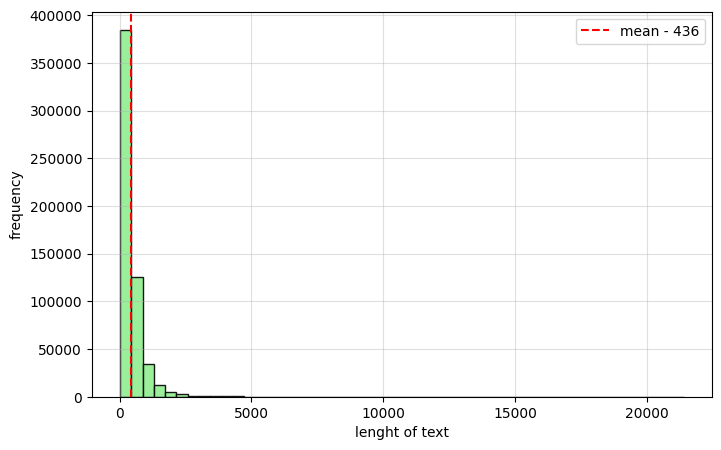

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['text_length'], bins= 50, color= 'lightgreen', alpha= 0.9, edgecolor= 'black')
plt.grid(alpha= 0.4)
plt.xlabel('lenght of text')
plt.ylabel('frequency')
plt.axvline(df_clean['text_length'].mean(), linestyle= '--', color = 'red', label = (f'mean - {df_clean['text_length'].mean() :.0f}'))
plt.legend()
plt.show()

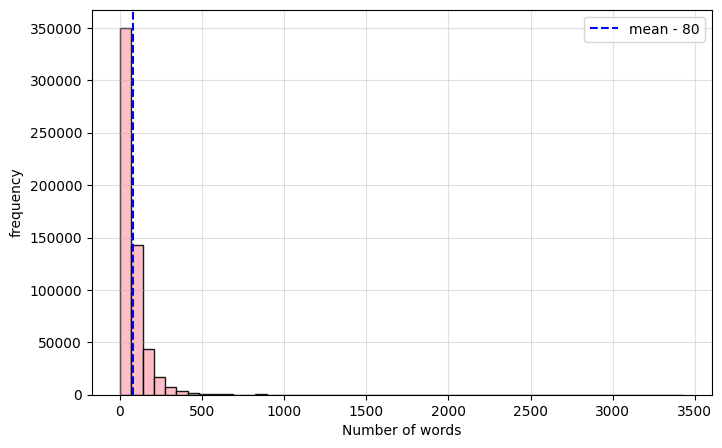

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['word_count'], bins= 50, color= 'lightpink', alpha= 0.9, edgecolor= 'black')
plt.grid(alpha= 0.4)
plt.xlabel('Number of words')
plt.ylabel('frequency')
plt.axvline(df_clean['word_count'].mean(), linestyle= '--', color = 'blue', label = (f'mean - {df_clean['word_count'].mean() :.0f}'))
plt.legend()
plt.show()

# divide the data for scoring
1,2 - neg - 0

4,5 - pos - 1

3 = removed all 3 my data , confused

In [18]:
df_binary = df_clean[df_clean['Score']!= 3].copy()
df_binary['sentiment'] = (df_binary['Score']>=4).astype(int)
df_binary

,Score,Text,text_length,word_count,sentiment
0,5,I have bought several of the Vitality canned d...,263,48,1
1,1,Product arrived labeled as Jumbo Salted Peanut...,190,31,0
2,4,This is a confection that has been around a fe...,509,94,1
3,2,If you are looking for the secret ingredient i...,219,41,0
4,5,Great taffy at a great price. There was a wid...,140,27,1
...,...,...,...,...,...
568449,5,Great for sesame chicken..this is a good if no...,149,26,1
568450,2,I'm disappointed with the flavor. The chocolat...,252,46,0
568451,5,"These stars are small, so you can give 10-15 o...",372,66,1
568452,5,These are the BEST treats for training and rew...,200,35,1


In [19]:
print(f"Original Dataset : {len(df_clean):,} reviews")
print(f"After removing 3 start revi : {len(df_binary):,} reviews")
print(f"\nClass Distribution")
print(f"Negative (1-2 stars) : {sum(df_binary['sentiment']==0):,}")
print(f"Positive (4-5 stars) : {sum(df_binary['sentiment']==1):,}")
print(f"\nClass Distribution Percentage")
neg_pct = (sum(df_binary['sentiment']==0) / len(df_binary)) * 100
pos_pct = (sum(df_binary['sentiment']==1) / len(df_binary)) * 100
print(f"Negative (1-2 stars) in % : {neg_pct:.2f}%")
print(f"Negative (4-5 stars) in % : {pos_pct:.2f}%")

Original Dataset : 568,454 reviews
After removing 3 start revi : 525,814 reviews

Class Distribution
Negative (1-2 stars) : 82,037
Positive (4-5 stars) : 443,777

Class Distribution Percentage
Negative (1-2 stars) in % : 15.60%
Negative (4-5 stars) in % : 84.40%


In [20]:
#there is a clear class imbalance, heavy imbalance

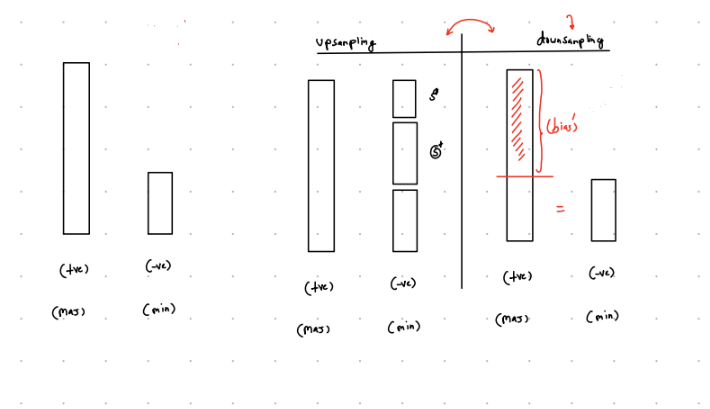

In [21]:
from sklearn.utils import resample

In [22]:
negative_review = df_binary[df_binary['sentiment']==0]
positive_review = df_binary[df_binary['sentiment']==1]

len(negative_review)

82037

In [23]:
len(positive_review)

443777

In [24]:
#downampling
n_minor = len(negative_review)
positive_downsampaled = resample(positive_review,
                                 replace = False, # duplicates are avoided
                                 n_samples = n_minor)

In [25]:
df_balanced = pd.concat([positive_downsampaled,negative_review])
#shuffles the entire dataset
df_balanced = df_balanced.sample(frac= 1).reset_index(drop = True)

In [26]:
df_balanced.head(2)

,Score,Text,text_length,word_count,sentiment
0,5,"Even though I do not have a gluten allergy, I ...",338,63,1
1,5,Rocky is a beautiful Collie but a very picky e...,303,58,1


In [27]:
df_balanced.head(15)

,Score,Text,text_length,word_count,sentiment
0,5,"Even though I do not have a gluten allergy, I ...",338,63,1
1,5,Rocky is a beautiful Collie but a very picky e...,303,58,1
2,5,I used this for making ice cream. It was quit...,74,15,1
3,1,"This review will make me sound really stupid, ...",4622,864,0
4,4,"Wonderful product at a great price, but it was...",158,31,1
5,1,"On Amazon.com the braided 12"" bully sticks thi...",548,85,0
6,2,"If you've got sensitive blood sugar, DO NOT ea...",490,79,0
7,1,We purchased two 24-count packages of Tully's ...,662,119,0
8,2,"I'm a fan of all-natural anything, especially ...",1664,283,0
9,5,I had bought the Tri-O-Plex bars from the comp...,713,126,1


In [28]:
print(f'-ve -> {sum(df_balanced['sentiment']==0)} ({sum(df_balanced['sentiment']==0)/len(df_balanced)* 100:.1f})')
print(f'+ve -> {sum(df_balanced['sentiment']==1)} ({sum(df_balanced['sentiment']==1)/len(df_balanced)* 100:.1f})')

-ve -> 82037 (50.0)
+ve -> 82037 (50.0)


In [29]:
df_balanced.shape

(164074, 5)

In [30]:
sample_size = 50000
df_sample = df_balanced.sample(n=sample_size)

In [31]:
df_sample.shape

(50000, 5)

In [32]:
#still 50,000 seperate sample - check on balance
sample_neg = sum(df_sample['sentiment']==0)
sample_pos =sum(df_sample['sentiment']==1)
print(f"\nClass Distribution")
print(f"Negative : {sample_neg:,} ({sample_neg/len(df_sample)*100:.2f}%)")
print(f"Positive : {sample_pos:,} ({sample_pos/len(df_sample)*100:.2f}%)")


Class Distribution
Negative : 25,046 (50.09%)
Positive : 24,954 (49.91%)


In [33]:
import re # regular expresion

In [34]:
#text processing
df_sample['Text'].iloc[4]

"Oh how I hate to buy dog food:  Lugging it into my basket; into the car; out of the car.  Hunt down the scissors or find a screw driver and rip that bad boy open where bugs will get in it or lift the whole heavy thing into a container.  This great new bag has a zipper on top and when I saw that I was happy!  Wow, I unzipped it and the bag unsealed and I didn't even need to pick the heavy ole thing to dump into the ice chest because I can get what I need and viola! Zipped that puppy right up.  That alone is something to look for if you lost several pairs of scissors in the garage.<br /><br />As to the food itself:  I've always felt good about Beneful:  It is colorful and smells good and my two rescued country dogs are not too picky.  Spikes wolfs down anything you put in front of him and looks at Baxter's bowl with lust. Baxter is a slower eater and we usually have to watch him to make sure he eats it all or empty it back into the container.  This time, Baxter ate it right up quickly a

Replacing the html tags and special symbols by blank space
<       : Start of tag

[^>]+   : One or more characters that are NOT '>'

'>'       : End of tag

In [35]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'<[^>]+>',' ', text) # catching all the tag and replace with empty space
  text = re.sub(r'[^a-zA-Z\s]', ' ', text) #anything which is not a-z/A-Z or blank space \s remove them
  return text

In [36]:
clean_text(df_sample['Text'].iloc[4])

'oh how i hate to buy dog food   lugging it into my basket  into the car  out of the car   hunt down the scissors or find a screw driver and rip that bad boy open where bugs will get in it or lift the whole heavy thing into a container   this great new bag has a zipper on top and when i saw that i was happy   wow  i unzipped it and the bag unsealed and i didn t even need to pick the heavy ole thing to dump into the ice chest because i can get what i need and viola  zipped that puppy right up   that alone is something to look for if you lost several pairs of scissors in the garage   as to the food itself   i ve always felt good about beneful   it is colorful and smells good and my two rescued country dogs are not too picky   spikes wolfs down anything you put in front of him and looks at baxter s bowl with lust  baxter is a slower eater and we usually have to watch him to make sure he eats it all or empty it back into the container   this time  baxter ate it right up quickly and no extr

In [37]:
df_sample['clean_text'] = df_sample['Text'].apply(clean_text)

In [38]:
df_sample.head(2)

,Score,Text,text_length,word_count,sentiment,clean_text
63606,5,We have Chihuahua's and they absolutely LOVE t...,783,157,1,we have chihuahua s and they absolutely love t...
61008,2,"<span class=""tiny""> Length:: 1:39 Mins<br /><b...",1102,180,0,length mins i am more of an espress...


In [39]:
MAX_FEATURES = 10000 #from al lthe data i need a vocab of size 10,000
MAX_LEN = 100 #standard


In [40]:
import tensorflow as tf

In [41]:
!pip install keras

In [42]:
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle

In [43]:
X = df_sample['clean_text'].values #Features
y = df_sample['sentiment'].values

In [44]:
tokenizers=  Tokenizer(num_words = MAX_FEATURES, oov_token = '<OOV>')
tokenizers.fit_on_texts(X)

X_sequence = tokenizers.texts_to_sequences(X)
X_padded = pad_sequences(X_sequence,
                         maxlen = MAX_LEN,
                         padding = 'post',
                         truncating = 'post')

In [45]:
print(X[1])

  length        mins   i am more of an espresso americano guy  but every now and then i really love a good cappuccino  this beverage tastes like the  cappuccino  you would get out of a gas station machine or a vending machine  the milk has a slightly weird taste and it is sweetened  why not let customers add sugar to taste rather than over sweeten the product  the drink is not strong or bold and as a little on the watery side when made according to the included instructions  it leaves you feeling really full and heavy not like a true cappuccino you would find in a local coffee shop  if you really want a cappuccino and have one of these machines  i think you d be a lot better pulling an  espresso  shot and adding your own fresh milk  yes  that does mean you ll need to froth it     note regarding video  the reason the saucer is cracked is due to bad product packaging for the  nescafe dolce gusto machine   this is how it arrived to me 


In [46]:
# See the first 10 words in our dictionary
print(list(tokenizers.word_index.items())[:11])

[('<OOV>', 1), ('the', 2), ('i', 3), ('and', 4), ('a', 5), ('it', 6), ('to', 7), ('of', 8), ('this', 9), ('is', 10), ('in', 11)]


In [47]:
print(f'text to sequence converted : \n{X[1].split()}\n{X_sequence[1]}')

text to sequence converted : 
['length', 'mins', 'i', 'am', 'more', 'of', 'an', 'espresso', 'americano', 'guy', 'but', 'every', 'now', 'and', 'then', 'i', 'really', 'love', 'a', 'good', 'cappuccino', 'this', 'beverage', 'tastes', 'like', 'the', 'cappuccino', 'you', 'would', 'get', 'out', 'of', 'a', 'gas', 'station', 'machine', 'or', 'a', 'vending', 'machine', 'the', 'milk', 'has', 'a', 'slightly', 'weird', 'taste', 'and', 'it', 'is', 'sweetened', 'why', 'not', 'let', 'customers', 'add', 'sugar', 'to', 'taste', 'rather', 'than', 'over', 'sweeten', 'the', 'product', 'the', 'drink', 'is', 'not', 'strong', 'or', 'bold', 'and', 'as', 'a', 'little', 'on', 'the', 'watery', 'side', 'when', 'made', 'according', 'to', 'the', 'included', 'instructions', 'it', 'leaves', 'you', 'feeling', 'really', 'full', 'and', 'heavy', 'not', 'like', 'a', 'true', 'cappuccino', 'you', 'would', 'find', 'in', 'a', 'local', 'coffee', 'shop', 'if', 'you', 'really', 'want', 'a', 'cappuccino', 'and', 'have', 'one', 'of

In [48]:
print(len(X_sequence[1]))

176


In [49]:
print(len(X[1].split()))

176


In [50]:
print(X_padded[1])

[3040 2830    3   91   52    8   74  707 7550 2023   17  177   94    4
  109    3   71   67    5   36 1428    9 1143  129   27    2 1428   18
   46   59   55    8    5 1035 2733  538   37    5 4153  538    2  218
   54    5  602  852   32    4    6   10 1199  278   15  397 1308  231
  118    7   32  414   63  126 2360    2   34    2  139   10   15  236
   37  505    4   26    5   93   25    2 1179  463   49  115 1200    7
    2 1186 1011    6  645   18  914   71  333    4  967   15   27    5
  706 1428]


In [51]:
#train test split
# we split the data into training and testing-> we do this to avoid data leakage!

In [52]:
x_train,x_test,y_train,y_test = train_test_split(X_padded,y,
                                                 test_size= 0.2,
                                                 stratify = y)

In [53]:
x_train.shape

(40000, 100)

In [54]:
x_test.shape

(10000, 100)

In [55]:
train_pos= sum(y_train)
test_pos = sum(y_test)
print(f' number of Positive reviews in training data: {train_pos}')
print(f' number of Positive reviews in testing data: {test_pos}')

 number of Positive reviews in training data: 19963
 number of Positive reviews in testing data: 4991


In [56]:
# - Embedding layer - convert word indices to dense vector,The Embedding layer turns meaningless numbers (IDs) into meaningful math (Vectors).
# - RNN - process sequences
# - Dropout layer - prevents overfitting
# - Dense layer - classification

In [57]:
def create_RNN_model():
  model= Sequential([
      Embedding(input_dim= MAX_FEATURES,  # "I know 10,000 unique words."
                output_dim= 128,          # "I will describe each word using 128 coordinates."
                input_length= MAX_LEN),      # "Every review I read will be exactly 150 words long."
      SimpleRNN(units=64, return_sequences= False),
      Dropout(0.5),
      Dense(32, activation = 'relu'),
      Dense(1,activation = 'sigmoid')
  ])
  return model

In [58]:
from sklearn import metrics
RNN_model = create_RNN_model()
RNN_model.compile(optimizer = 'adam',
                  metrics = ['accuracy'],
                  loss = 'binary_crossentropy')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [59]:
earlyl_stoping = EarlyStopping (
    monitor= 'val_loss',
    patience=5,
    restore_best_weights= True,
    verbose = 1
    )
#model checkpoints

checkpoints = ModelCheckpoint(
    'best_RNN/RNN_model.keras',
    monitor= 'val_accuravy',
    save_best_only = True,
    verbose =1,
    mode = 'max',
)

In [60]:
RNN_history = RNN_model.fit(
    x_train,y_train,
    batch_size = 128,
    epochs = 5,
    validation_split = 0.20,
    #callbacks= [earlyl_stoping, checkpoints]
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.5378 - loss: 0.6868 - val_accuracy: 0.5247 - val_loss: 0.6907
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.5238 - loss: 0.6909 - val_accuracy: 0.5240 - val_loss: 0.6892
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5578 - loss: 0.6690 - val_accuracy: 0.5479 - val_loss: 0.6901
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6265 - loss: 0.5893 - val_accuracy: 0.5515 - val_loss: 0.7327
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6680 - loss: 0.5195 - val_accuracy: 0.5430 - val_loss: 0.8487


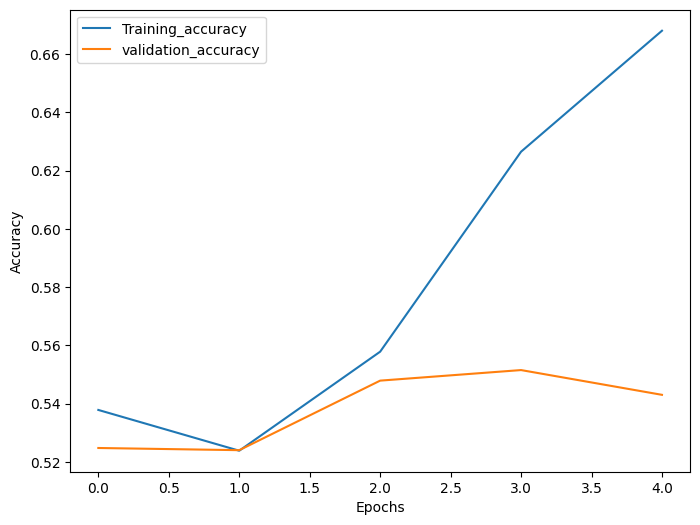

In [61]:
plt.figure(figsize = (8,6))
plt.plot(RNN_history.history['accuracy'], label = 'Training_accuracy')
plt.plot(RNN_history.history['val_accuracy'], label = 'validation_accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

LSTM Model

In [62]:
def create_Lstm_model():
  model_1 = Sequential([
      Embedding(input_dim= MAX_FEATURES,
                   output_dim= 128,
                   input_length = MAX_LEN),
      LSTM(units = 64, return_sequences= False),
      Dropout(0.50),
      Dense(32, activation= 'relu'),
      Dense(1, activation= 'sigmoid' )
  ])
  return model_1

lstm_model = create_Lstm_model()
lstm_model.compile(
    optimizer= 'adam',
    metrics= ['accuracy'],
    loss= 'binary_crossentropy'
)

#fit model
lstm_model_history = lstm_model.fit(
    x_train, y_train,
    batch_size = 128,
    epochs = 5,
    validation_split = 0.20,
    callbacks = [earlyl_stoping, checkpoints]
)

Epoch 1/5
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5349 - loss: 0.6858
Epoch 1: finished saving model to best_RNN/RNN_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5784 - loss: 0.6730 - val_accuracy: 0.6118 - val_loss: 0.6567
Epoch 2/5
  7/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6243 - loss: 0.6496 

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuravy available.
  if self._should_save_model(epoch, batch, logs, filepath):


245/250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6173 - loss: 0.6573
Epoch 2: finished saving model to best_RNN/RNN_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6218 - loss: 0.6545 - val_accuracy: 0.7220 - val_loss: 0.5989
Epoch 3/5
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6095 - loss: 0.6526
Epoch 3: finished saving model to best_RNN/RNN_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5683 - loss: 0.6722 - val_accuracy: 0.5955 - val_loss: 0.6565
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6302 - loss: 0.6273
Epoch 4: finished saving model to best_RNN/RNN_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6997 - loss: 0.5704 - val_accuracy: 0.8044 - val_loss: 0.4839
Epoch 5/5
244/250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8320 - loss: 0.4241
Epoch 5: finished saving model to best_RNN/RNN_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8514 - loss: 0.3827 - va

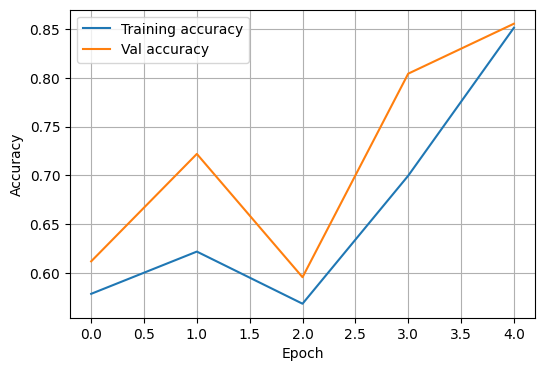

In [63]:
#plot the model
plt.figure(figsize=(6,4))
plt.plot(lstm_model_history.history['accuracy'],label='Training accuracy')
plt.plot(lstm_model_history.history['val_accuracy'],label='Val accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

GRU Model

In [64]:
def create_gru_model():
  model_3 = Sequential([
      Embedding(input_dim= MAX_FEATURES,
                   output_dim= 128,
                   input_length = MAX_LEN),
      GRU(units= 64, return_sequences= False),
      Dropout(0.50),
      Dense(32, activation='relu'),
      Dense(1, activation= 'sigmoid')
  ])
  return model_3


gru_model = create_gru_model()
gru_model.compile(
    optimizer= 'adam',
    metrics= ['accuracy'],
    loss = 'binary_crossentropy'
)


gru_model_history= gru_model.fit(
    x_train, y_train,
    batch_size= 128,
    epochs= 5,
    validation_split= 0.20
   # callbacks = [earlyl_stoping, checkpoints]
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5238 - loss: 0.6910 - val_accuracy: 0.5374 - val_loss: 0.6906
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5877 - loss: 0.6631 - val_accuracy: 0.7319 - val_loss: 0.6092
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5727 - loss: 0.6651 - val_accuracy: 0.5654 - val_loss: 0.6761
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5433 - loss: 0.6786 - val_accuracy: 0.5420 - val_loss: 0.6842
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5563 - loss: 0.6689 - val_accuracy: 0.7826 - val_loss: 0.5698


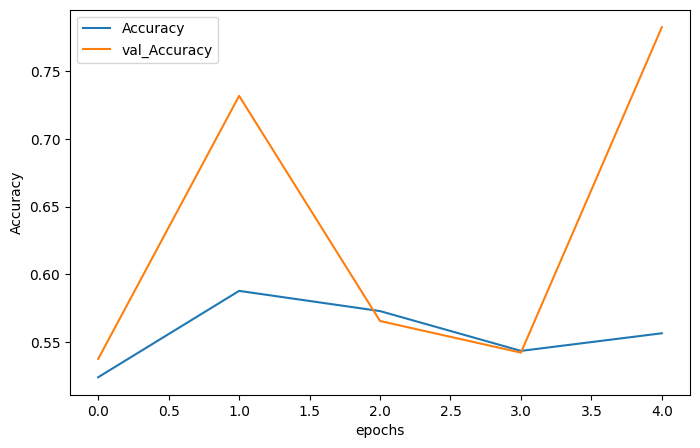

In [65]:
plt.figure(figsize= (8,5))
plt.plot(gru_model_history.history['accuracy'], label= 'Accuracy')
plt.plot(gru_model_history.history['val_accuracy'], label= 'val_Accuracy')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

BI-LSTM Model

In [66]:
def create_bilstm_model():
  model_4= Sequential([
      Embedding(input_dim= MAX_FEATURES,
                output_dim= 128,
                input_length= MAX_LEN),
      Bidirectional(LSTM(64, return_sequences= True)),
      Dropout(0.30),
      Bidirectional(LSTM(64)),
      Dropout(0.30),
      Dense(1, activation= 'sigmoid')
  ])
  return model_4

bilstm_model= create_bilstm_model()

#compile
bilstm_model.compile(
    optimizer = 'adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#fit
bilstm_model_history= bilstm_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs= 5,
    validation_split= 0.20
    # callbacks = [earlyl_stoping, checkpoints]
)




Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8077 - loss: 0.4173 - val_accuracy: 0.8745 - val_loss: 0.3071
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9018 - loss: 0.2528 - val_accuracy: 0.8767 - val_loss: 0.2935
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9297 - loss: 0.1892 - val_accuracy: 0.8849 - val_loss: 0.3071
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9510 - loss: 0.1413 - val_accuracy: 0.8842 - val_loss: 0.3348
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9645 - loss: 0.1068 - val_accuracy: 0.8859 - val_loss: 0.3554


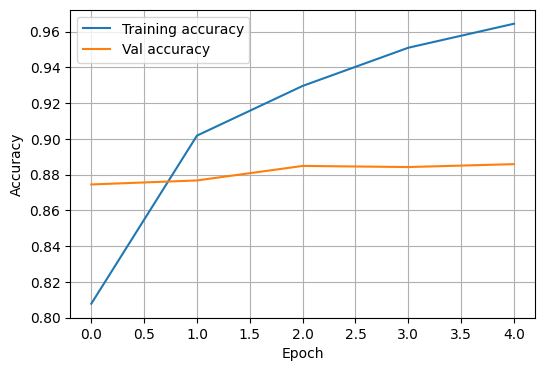

In [67]:
#plot the model
plt.figure(figsize=(6,4))
plt.plot(bilstm_model_history.history['accuracy'],label='Training accuracy')
plt.plot(bilstm_model_history.history['val_accuracy'],label='Val accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

BI-GRU model

In [68]:
def create_bigru_model():
  model_4= Sequential([
      Embedding(input_dim= MAX_FEATURES,
                output_dim= 128,
                input_length= MAX_LEN),
      Bidirectional(GRU(64, return_sequences= True)),
      Dropout(0.30),
      Bidirectional(LSTM(64)),
      Dropout(0.30),
      Dense(1, activation= 'sigmoid')
  ])
  return model_4

bigru_model= create_bigru_model()

#compile
bigru_model.compile(
    optimizer = 'adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#fit
bigru_model_history= bigru_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs= 5,
    validation_split= 0.20
    # callbacks = [earlyl_stoping, checkpoints]
)


Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.7958 - loss: 0.4342 - val_accuracy: 0.8785 - val_loss: 0.3027
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8986 - loss: 0.2620 - val_accuracy: 0.8844 - val_loss: 0.2834
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9273 - loss: 0.1961 - val_accuracy: 0.8865 - val_loss: 0.3080
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9446 - loss: 0.1562 - val_accuracy: 0.8885 - val_loss: 0.3333
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9584 - loss: 0.1218 - val_accuracy: 0.8895 - val_loss: 0.3498


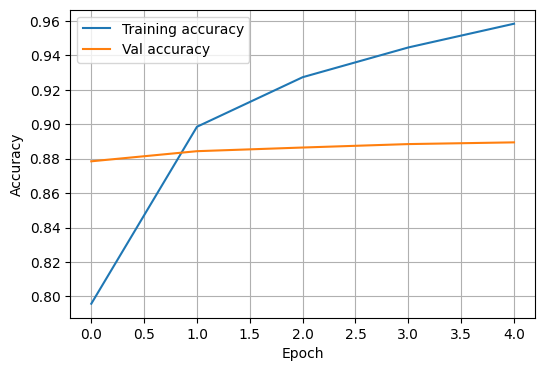

In [69]:
#plot the model
plt.figure(figsize=(6,4))
plt.plot(bigru_model_history.history['accuracy'],label='Training accuracy')
plt.plot(bigru_model_history.history['val_accuracy'],label='Val accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

In [70]:
!rm -rf my_dir